In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, roc_auc_score, f1_score, recall_score, precision_score, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
from imblearn.pipeline import Pipeline 
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, StratifiedKFold


In [8]:
df = pd.read_csv("data/train-cat-encoded.csv")
print("Training set size: ", df.shape)
# test_df = pd.read_csv("data/test-cat-encoded.csv")
# print("Testing set size: ", test_df.shape)


Training set size:  (668665, 22)


In [9]:
y = df['Will_Buy_EV']
x = df.drop(columns=['Will_Buy_EV'])
# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


## Build Baseline model

In [10]:
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
smote = SMOTE(random_state=42)
subsetNum = 100000
subset_x = x.iloc[:subsetNum]
subset_y = y.iloc[:subsetNum]


In [11]:
def gini_score(y_true, y_pred_probabilities):
    """Calculates the Normalized Gini Coefficient"""
    auc = roc_auc_score(y_true, y_pred_probabilities)
    return 2 * auc - 1



========== FOLD 1 ==========
Fold 1 | Gini: 0.5898 | AUC: 0.7949
F1: 0.6724 | Recall: 0.6491 | Precision: 0.6974


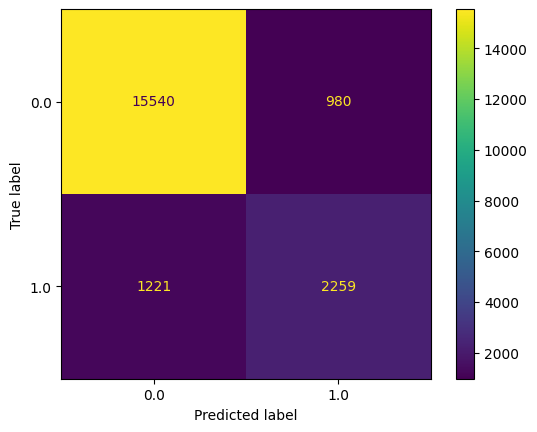

Finished Fold 1

========== FOLD 2 ==========
Fold 2 | Gini: 0.5928 | AUC: 0.7964
F1: 0.6767 | Recall: 0.6497 | Precision: 0.7061


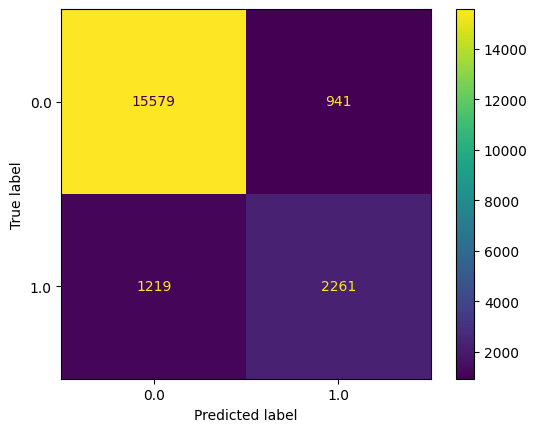

Finished Fold 2

========== FOLD 3 ==========
Fold 3 | Gini: 0.5875 | AUC: 0.7937
F1: 0.6713 | Recall: 0.6463 | Precision: 0.6984


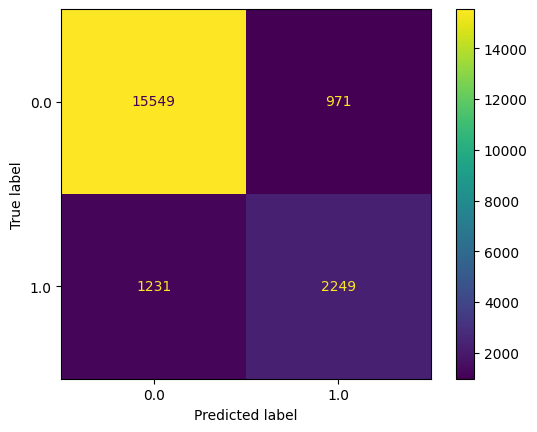

Finished Fold 3

========== FOLD 4 ==========
Fold 4 | Gini: 0.5912 | AUC: 0.7956
F1: 0.6735 | Recall: 0.6504 | Precision: 0.6983


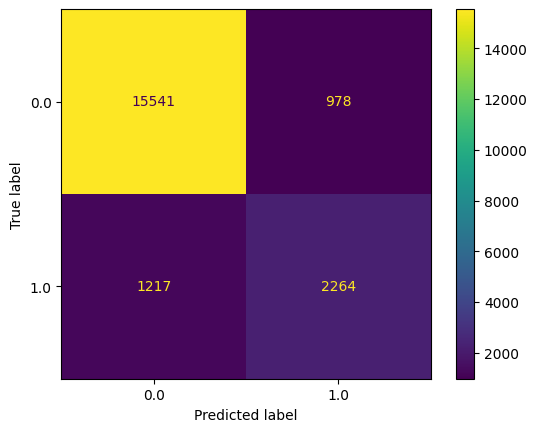

Finished Fold 4

========== FOLD 5 ==========
Fold 5 | Gini: 0.5949 | AUC: 0.7975
F1: 0.6783 | Recall: 0.6518 | Precision: 0.7071


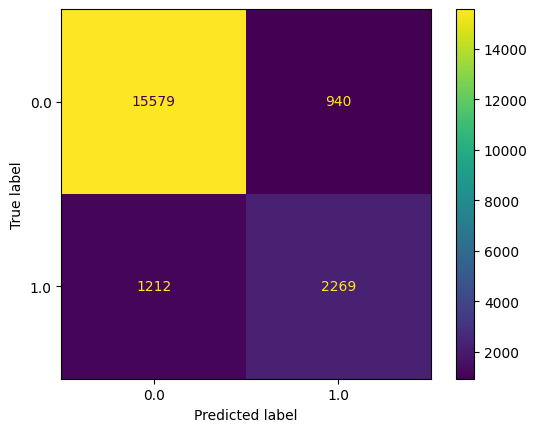

Finished Fold 5
Avg AUC: 0.7956
Std AUC: 0.0012637600494317049


In [12]:
aucList = []
# X and y should be pandas DataFrames/Series or numpy arrays
for fold, (train_idx, val_idx) in enumerate(skf.split(subset_x, subset_y)):
    print(f"\n========== FOLD {fold + 1} ==========")
    
    # 1. Split data (using .iloc if X/y are pandas DataFrames)
    X_train, X_val = subset_x.iloc[train_idx], subset_x.iloc[val_idx]
    y_train, y_val = subset_y.iloc[train_idx], subset_y.iloc[val_idx]
    
    # 2. Apply SMOTE ONLY to the training data for this fold
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    
    model = RandomForestClassifier(random_state=42, criterion='gini')
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_val)
    gini = gini_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)

    print(f"Fold {fold + 1} | Gini: {gini:.4f} | AUC: {auc:.4f}")
    print(f"F1: {f1:.4f} | Recall: {recall:.4f} | Precision: {precision:.4f}")
    ConfusionMatrixDisplay.from_predictions(y_val, y_pred)
    plt.show()
    aucList.append(auc)
              
    print(f"Finished Fold {fold + 1}")

print(f"Avg AUC: {(sum(aucList) / n_splits):.4f}")
print(f"Std AUC: {np.std(aucList)}")
